# 06 — Model Evaluation & Business Insights

## Objective
Go deeper into the best model (Random Forest + SMOTE) to understand:
- WHY it makes specific predictions (multi-class SHAP)
- WHERE it performs well vs poorly per class (segment analysis)
- HOW threshold tuning changes the precision-recall tradeoff
- WHAT business decisions this model can support

## This Notebook Answers
1. What does SHAP tell us about individual predictions?
2. Does model performance vary by hour of day per class?
3. Does model performance vary by zone per class?
4. Does weather affect prediction quality?
5. What happens when we tune the classification threshold?
6. What is the business recommendation?

## Key Difference from Surge Pricing Evaluation
Surge pricing had one output (surge value) — one SHAP explanation.
Cancellation prediction has three outputs (three class probabilities)
— three SHAP explanations per prediction. We can explain why the
model thought "Completed" was likely AND why it thought
"Driver Cancel" was unlikely — for the same ride.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling   import SMOTE

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

OUTCOME_COLORS = {0: "#4CAF50", 1: "#F44336", 2: "#FF9800"}
OUTCOME_LABELS = {0: "Completed", 1: "Driver Cancel", 2: "User Cancel"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH       = "../data/processed/"
MODELS_DIR = "../models/"

modeling_df = pd.read_csv(PATH + "modeling_data.csv")
rides_eng   = pd.read_csv(PATH + "rides_engineered.csv")

with open(PATH + "feature_cols.pkl", "rb") as f:
    feature_cols = pickle.load(f)

TARGET = "ride_outcome"
X = modeling_df[feature_cols]
y = modeling_df[TARGET]

# Recreate exact same split as notebook 05
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Recreate SMOTE training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Load and retrain best model
# (pickle saves model state but we retrain for clean SHAP compatibility)
from sklearn.ensemble import RandomForestClassifier
best_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_leaf=10, n_jobs=-1, random_state=42
)
best_model.fit(X_train_smote, y_train_smote)

print("Model retrained on SMOTE data ✅")
print(f"  X_test shape : {X_test.shape}")

Model retrained on SMOTE data ✅
  X_test shape : (12000, 35)


In [3]:
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Build evaluation dataframe
eval_df = X_test.copy().reset_index(drop=True)
eval_df["actual_outcome"]    = y_test.values
eval_df["predicted_outcome"] = y_pred
eval_df["prob_completed"]    = y_pred_proba[:, 0]
eval_df["prob_driver_cancel"]= y_pred_proba[:, 1]
eval_df["prob_user_cancel"]  = y_pred_proba[:, 2]
eval_df["correct"]           = (eval_df["actual_outcome"] == eval_df["predicted_outcome"]).astype(int)

print("Predictions generated ✅")
print(f"\nOverall Performance:")
print(classification_report(
    y_test, y_pred,
    target_names=[OUTCOME_LABELS[k] for k in [0,1,2]]
))

Predictions generated ✅

Overall Performance:
               precision    recall  f1-score   support

    Completed       0.81      0.76      0.78      9320
Driver Cancel       0.10      0.15      0.12       784
  User Cancel       0.25      0.29      0.27      1896

     accuracy                           0.64     12000
    macro avg       0.39      0.40      0.39     12000
 weighted avg       0.68      0.64      0.66     12000



## Section 1 — Predicted Probability Distributions

### Why This Matters
The model outputs three probabilities per ride:
- P(Completed), P(Driver Cancel), P(User Cancel)
These must sum to 1.0 for each ride.

Understanding how these probabilities are distributed
tells us how CONFIDENT the model is in its predictions.

A model that frequently predicts 0.45 / 0.30 / 0.25
(nearly equal for all three classes) is uncertain —
it cannot distinguish the outcomes clearly.

A model that frequently predicts 0.90 / 0.05 / 0.05
is confident — it knows when a ride will complete.

We care especially about Driver Cancel probabilities —
how high does P(Driver Cancel) need to be before the
model actually predicts Driver Cancel?

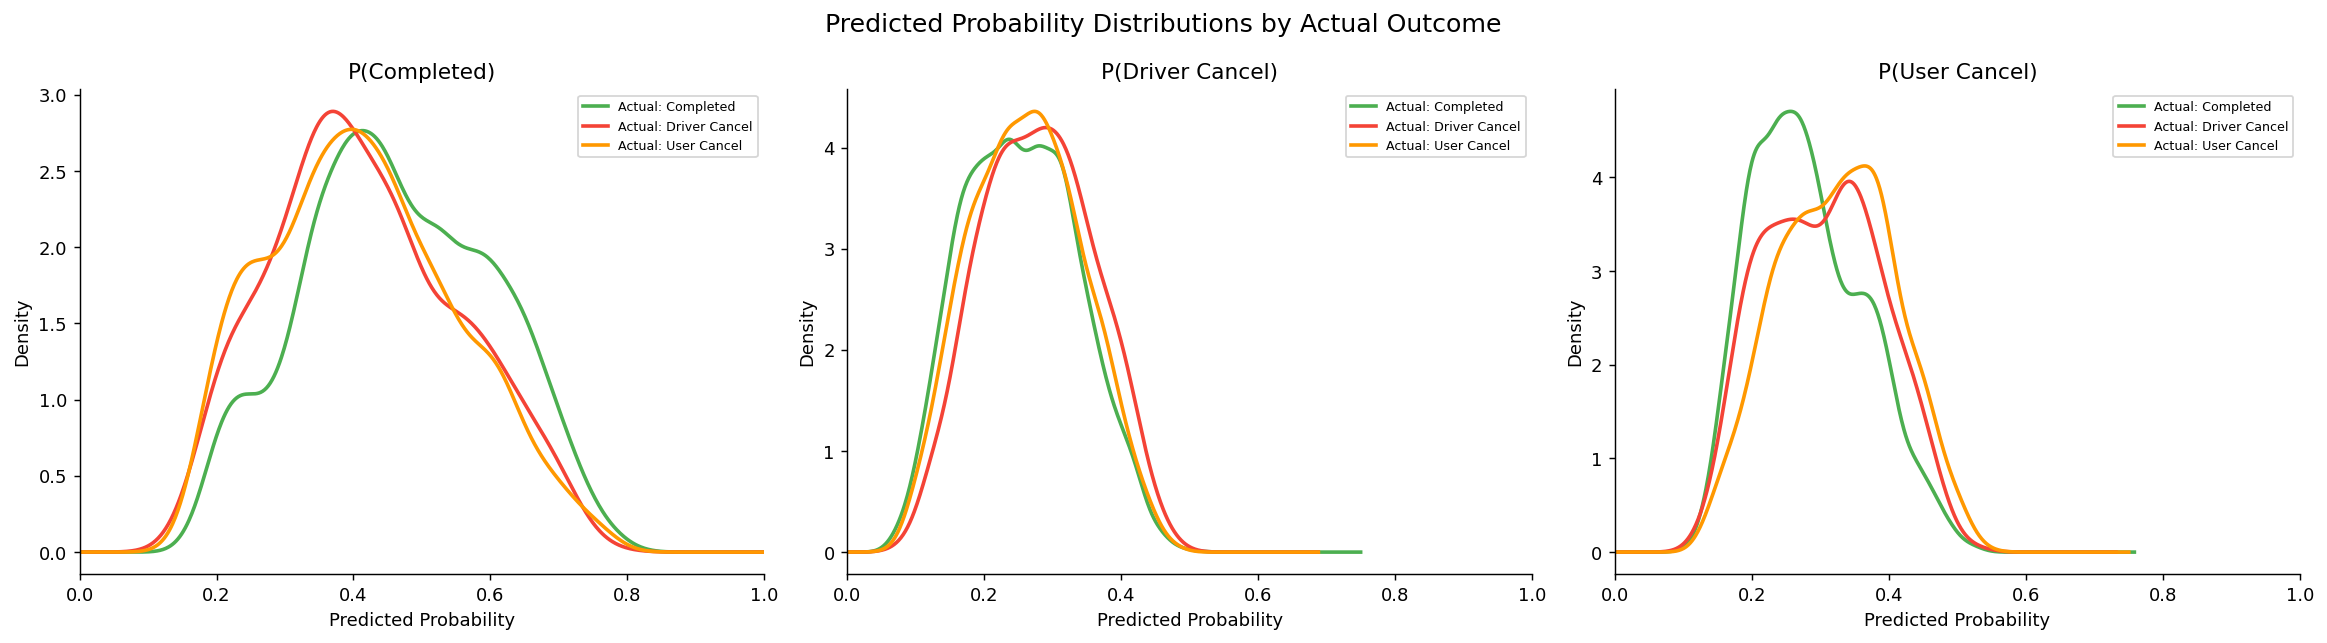

Mean predicted probabilities by actual outcome:
                prob_completed  prob_driver_cancel  prob_user_cancel
actual_outcome                                                      
0                       0.4642              0.2540            0.2818
1                       0.4178              0.2785            0.3037
2                       0.4141              0.2624            0.3235


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Predicted Probability Distributions by Actual Outcome",
             fontsize=14)

prob_cols = ["prob_completed", "prob_driver_cancel", "prob_user_cancel"]
titles    = ["P(Completed)", "P(Driver Cancel)", "P(User Cancel)"]

for idx, (prob_col, title) in enumerate(zip(prob_cols, titles)):
    for k in [0, 1, 2]:
        subset = eval_df[eval_df["actual_outcome"] == k][prob_col]
        subset.plot.kde(
            ax=axes[idx],
            color=OUTCOME_COLORS[k],
            linewidth=2,
            label=f"Actual: {OUTCOME_LABELS[k]}"
        )
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Predicted Probability")
    axes[idx].set_ylabel("Density")
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../data/processed/eval_01_prob_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Mean predicted probabilities by actual outcome:")
print(eval_df.groupby("actual_outcome")[prob_cols].mean().round(4))

## Section 2 — Multi-Class SHAP Analysis

### What SHAP Tells Us Here
In surge pricing, SHAP gave one value per feature per prediction
showing "this feature pushed the predicted surge UP by X."

Here, SHAP gives THREE values per feature per prediction:
- How much did this feature push P(Completed) up or down?
- How much did this feature push P(Driver Cancel) up or down?
- How much did this feature push P(User Cancel) up or down?

This lets us answer: "for this specific ride, what made the
model think it was going to be cancelled by the driver?"

We focus our SHAP analysis on the Driver Cancel class —
the rarest and hardest class — because understanding what
drives those predictions is most actionable for the business.

In [14]:
print("Computing SHAP values (this may take 2-3 minutes)...")

explainer   = shap.TreeExplainer(best_model)
sample_size = 1500
X_sample    = X_test.sample(sample_size, random_state=42)

shap_values_raw = explainer.shap_values(X_sample)

if isinstance(shap_values_raw, list) and len(shap_values_raw) == sample_size:
    shap_values = np.stack(shap_values_raw, axis=0)
elif isinstance(shap_values_raw, list) and len(shap_values_raw) == 3:
    shap_values = np.array(shap_values_raw)
else:
    shap_values = np.array(shap_values_raw)

# shap_values is now either:
# - shape (n_samples, n_features, n_classes) when the explainer returns per-sample arrays
# - shape (n_classes, n_samples, n_features) when the explainer returns per-class arrays

if shap_values.ndim == 3 and shap_values.shape[0] == sample_size:
    shap_values_driver_cancel = shap_values[:, :, 1]
    shap_values_user_cancel   = shap_values[:, :, 2]
    print("SHAP values computed ✅")
    print(f"  Sample size      : {sample_size:,}")
    print(f"  SHAP array shape : {shap_values.shape}")
    print(f"  Features         : {shap_values.shape[1]}")
    print(f"  Classes          : {shap_values.shape[2]}")
else:
    shap_values_driver_cancel = shap_values[1]
    shap_values_user_cancel   = shap_values[2]
    print("SHAP values computed ✅")
    print(f"  Sample size      : {sample_size:,}")
    print(f"  SHAP value shape : {getattr(shap_values, 'shape', None)}")

Computing SHAP values (this may take 2-3 minutes)...
SHAP values computed ✅
  Sample size      : 1,500
  SHAP array shape : (1500, 35, 3)
  Features         : 35
  Classes          : 3


SHAP Summary — Driver Cancel Class


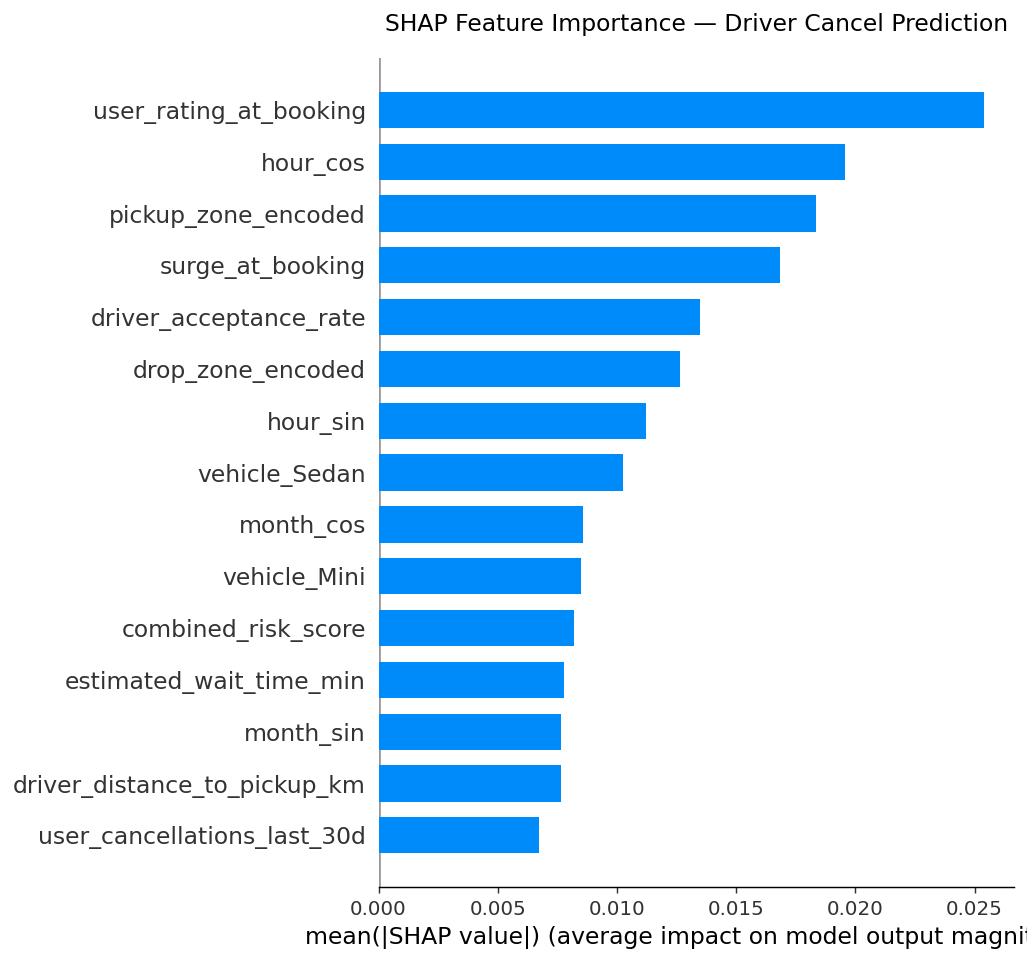

In [15]:
# Focus on Driver Cancel (class 1) — most actionable
print("SHAP Summary — Driver Cancel Class")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — Driver Cancel Prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_02_shap_driver_cancel.png",
            dpi=150, bbox_inches="tight")
plt.show()

SHAP Summary — User Cancel Class


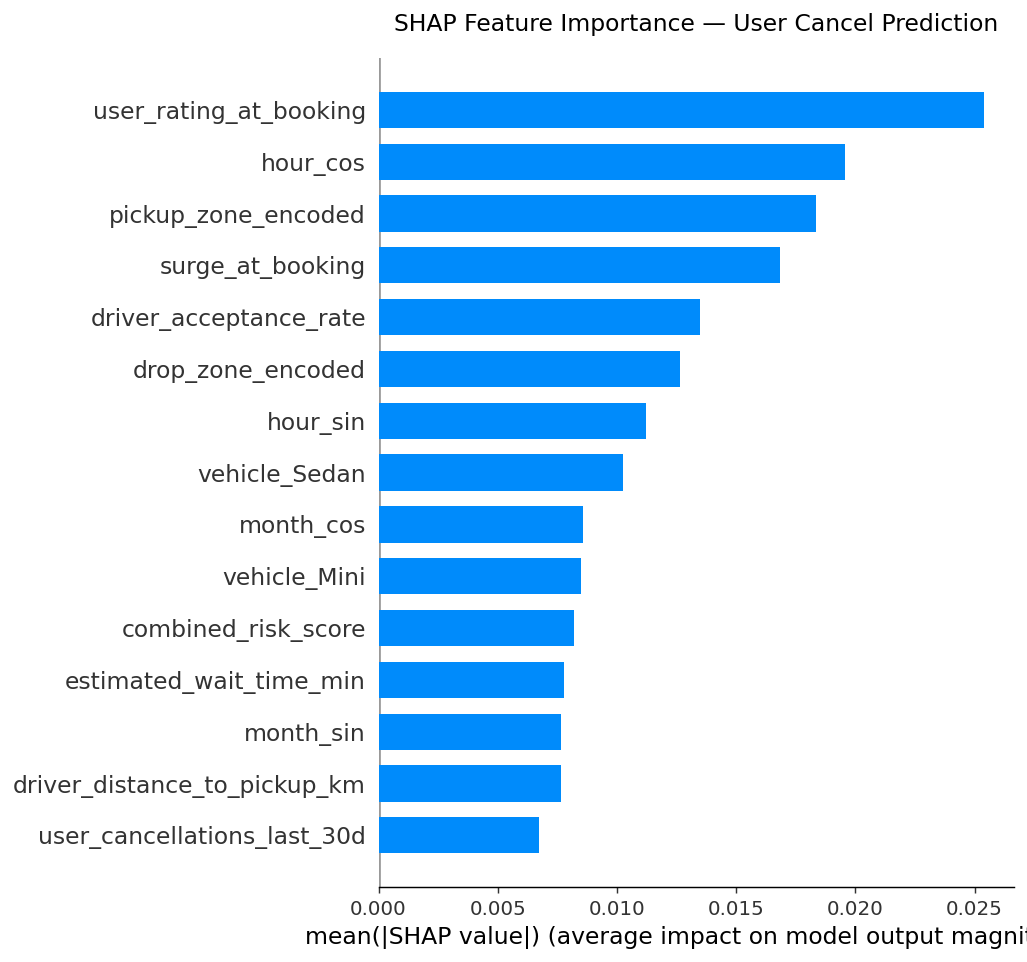

In [17]:
print("SHAP Summary — User Cancel Class")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — User Cancel Prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_03_shap_user_cancel.png",
            dpi=150, bbox_inches="tight")
plt.show()

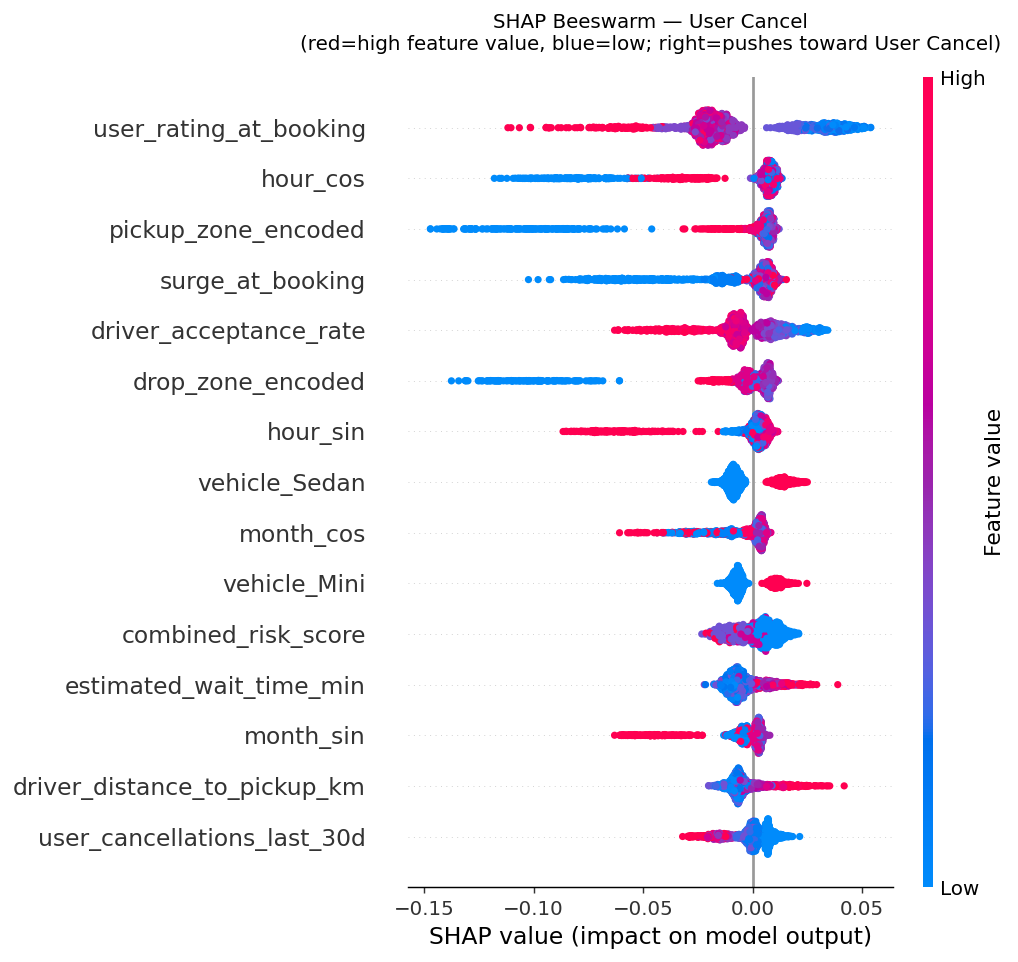

In [19]:
# Beeswarm shows direction AND magnitude for each feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="dot"
)
plt.title("SHAP Beeswarm — User Cancel\n"
          "(red=high feature value, blue=low; right=pushes toward User Cancel)",
          fontsize=11, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_04_shap_beeswarm_user.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Explain 3 specific rides:
# 1. A correctly predicted Driver Cancel
# 2. A correctly predicted User Cancel
# 3. A misclassified Driver Cancel (predicted as Completed)

# Find examples
correct_driver = eval_df[
    (eval_df["actual_outcome"] == 1) &
    (eval_df["predicted_outcome"] == 1)
].index

correct_user = eval_df[
    (eval_df["actual_outcome"] == 2) &
    (eval_df["predicted_outcome"] == 2)
].index

missed_driver = eval_df[
    (eval_df["actual_outcome"] == 1) &
    (eval_df["predicted_outcome"] == 0)
].index

examples = {}
if len(correct_driver) > 0:
    examples["Correctly Predicted Driver Cancel"] = correct_driver[0]
if len(correct_user) > 0:
    examples["Correctly Predicted User Cancel"] = correct_user[0]
if len(missed_driver) > 0:
    examples["Missed Driver Cancel (predicted Completed)"] = missed_driver[0]

for title, idx in examples.items():
    row = X_test.iloc[[idx]]
    sv  = explainer.shap_values(row)

    actual    = eval_df.loc[idx, "actual_outcome"]
    predicted = eval_df.loc[idx, "predicted_outcome"]

    print(f"\n{'='*60}")
    print(f" {title}")
    print(f"  Actual    : {OUTCOME_LABELS[actual]}")
    print(f"  Predicted : {OUTCOME_LABELS[predicted]}")
    print(f"  Probabilities:")
    print(f"    Completed    : {eval_df.loc[idx,'prob_completed']:.3f}")
    print(f"    Driver Cancel: {eval_df.loc[idx,'prob_driver_cancel']:.3f}")
    print(f"    User Cancel  : {eval_df.loc[idx,'prob_user_cancel']:.3f}")
    print(f"\n  Top features for this prediction:")

    # Show top 5 SHAP values for the actual class
    class_idx = actual
    sv_array = np.array(sv)
    if isinstance(sv, list) and len(sv) == 3:
        shap_values_row = sv[class_idx]
        shap_row = pd.Series(shap_values_row.ravel(), index=feature_cols)
    elif sv_array.ndim == 3 and sv_array.shape[0] == 1:
        shap_row = pd.Series(sv_array[0, :, class_idx], index=feature_cols)
    elif sv_array.ndim == 2 and sv_array.shape[0] == len(feature_cols):
        shap_row = pd.Series(sv_array[:, class_idx], index=feature_cols)
    elif sv_array.ndim == 2 and sv_array.shape[1] == len(feature_cols):
        shap_row = pd.Series(sv_array[0, :, class_idx], index=feature_cols)
    else:
        shap_row = pd.Series(sv_array.ravel(), index=feature_cols)

    top5 = shap_row.abs().sort_values(ascending=False).head(5)
    for feat, val in top5.items():
        direction = "↑" if shap_row[feat] > 0 else "↓"
        feat_val  = row[feat].values[0]
        print(f"    {feat:<35} {direction} {abs(shap_row[feat]):.4f}  (value={feat_val:.3f})")


 Correctly Predicted Driver Cancel
  Actual    : Driver Cancel
  Predicted : Driver Cancel
  Probabilities:
    Completed    : 0.233
    Driver Cancel: 0.415
    User Cancel  : 0.351

  Top features for this prediction:


IndexError: index 1 is out of bounds for axis 0 with size 1